# Forecast for Picnic Weather
## Base Model

Fit base model with processed dataset

Use RandomForestCassifier as first approach

---

## 1. Load Modules & Load Data



In [1]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from core.data import load_from_kaggle

# Styling für bessere Visualisierungen
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# GeoPy with Nominatim to estimate lat, lon from city name
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import os
import time
import requests     # um die OpenAPI für Höhenangaben bei lat, lon abzufragen

# Meteostat for weather data
from datetime import date
import meteostat as ms

# Models
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.inspection import permutation_importance

# import module for Score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import cross_val_score

c:\Users\Trainee\Documents\dpp\portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm




## 2. Daten einlesen & erste Inspektion



In [2]:

file_weather_FS    = '../data/processed/weather_FS_lat_lon_elevation.csv'
file_weather_meteostat    = '../data/processed/weather_meteostat_lat_lon_elevation.csv'

# For extended analysis, you could also load the complete dataset if needed
weather_FS = pd.read_csv(file_weather_FS, 
                           delimiter=',', encoding='ascii', parse_dates=['DATE'])
print(f"📊 Geladene Datei: {file_weather_FS}")
print(f"📏 Shape: {weather_FS.shape[0]:,} Zeilen × {weather_FS.shape[1]} Spalten\n")

# For extended analysis, you could also load the complete dataset if needed
meteostat = pd.read_csv(file_weather_meteostat, 
                           delimiter=',', encoding='ascii', parse_dates=['DATE'])
print(f"📊 Geladene Datei: {file_weather_meteostat}")
print(f"📏 Shape: {meteostat.shape[0]:,} Zeilen × {meteostat.shape[1]} Spalten\n")

# Convert the DATE column to datetime. The DATE is given as an integer (likely in YYYYMMDD format)
# for df in [weather_FS, meteostat]:
#     df['DATE'] = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d', errors='coerce')

print('Data loaded and DATE column converted to datetime.')

display(weather_FS.sample(3))
meteostat.sample(3)

weather_FS.info()
meteostat.info()


📊 Geladene Datei: ../data/processed/weather_FS_lat_lon_elevation.csv
📏 Shape: 62,118 Zeilen × 18 Spalten

📊 Geladene Datei: ../data/processed/weather_meteostat_lat_lon_elevation.csv
📏 Shape: 58,379 Zeilen × 18 Spalten

Data loaded and DATE column converted to datetime.


,DATE,MONTH,cloud_cover,wind_speed,wind_gust,humidity,pressure,global_radiation,precipitation,sunshine,temp_mean,temp_min,temp_max,city,picnic_weather,lat,lon,elevation
59093,2001-09-21,9,NaN,2.5,NaN,0.82,1.0163,1.86,0.04,NaN,13.4,7.8,19.1,TOURS,False,47.390047,0.688927,55.0
36197,2009-01-24,1,NaN,2.3,NaN,NaN,NaN,NaN,0.07,NaN,2.9,2.2,3.5,MALMO,False,55.605293,13.000157,14.0
19994,2004-09-20,9,7.0,NaN,NaN,0.68,1.0091,0.87,0.18,2.0,16.6,13.8,16.7,HEATHROW,False,51.467739,-0.458780,16.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62118 entries, 0 to 62117
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   DATE              62118 non-null  datetime64[ns]
 1   MONTH             62118 non-null  int64         
 2   cloud_cover       43848 non-null  float64       
 3   wind_speed        43848 non-null  float64       
 4   wind_gust         25578 non-null  float64       
 5   humidity          54810 non-null  float64       
 6   pressure          51156 non-null  float64       
 7   global_radiation  54810 non-null  float64       
 8   precipitation     62118 non-null  float64       
 9   sunshine          47502 non-null  float64       
 10  temp_mean         62118 non-null  float64       
 11  temp_min          58464 non-null  float64       
 12  temp_max          62118 non-null  float64       
 13  city              62118 non-null  object        
 14  picnic_weather    6211



---

## 3. Datenqualität & Struktur



In [3]:
# Func Def: Overview(df) Übersicht entwerfen, um immer mal wieder einen schnellen Überblick über die wichtigsten "Metadaten" zu bekommen
def overview(df):
    '''
    Erstelle einen Überblick über einige wichtige Eigenschaften der Spalten eines DataFrames.
    VARs
        df: Der zu betrachtende DataFrame
    RETURNS:
        None
    '''
    df = df.copy()
    display(pd.DataFrame({'dtype': df.dtypes,
                          'total': df.count(),
                          'missing_n': df.isna().sum(),
                          'missing_%': df.isna().mean()*100,
                          'uniques_n': df.nunique(),
                          'uniques': [df[col].unique() for col in df.columns]
                         }))

In [4]:
overview(weather_FS)
overview(meteostat)

,dtype,total,missing_n,missing_%,uniques_n,uniques
DATE,datetime64[ns],62118,0,0.000000,3654,"[2000-01-01 00:00:00, 2000-01-02 00:00:00, 200..."
MONTH,int64,62118,0,0.000000,12,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
cloud_cover,float64,43848,18270,29.411765,11,"[8.0, 5.0, 7.0, 3.0, 4.0, 1.0, 0.0, 6.0, 2.0, ..."
wind_speed,float64,43848,18270,29.411765,140,"[nan, 2.5, 3.7, 6.1, 3.8, 4.0, 5.2, 4.8, 4.3, ..."
wind_gust,float64,25578,36540,58.823529,271,"[nan, 8.0, 9.0, 13.0, 15.0, 12.0, 11.0, 7.0, 5..."
humidity,float64,54810,7308,11.764706,84,"[0.89, 0.87, 0.81, 0.79, 0.9, 0.85, 0.84, 0.88..."
pressure,float64,51156,10962,17.647059,692,"[1.0286, 1.0318, 1.0314, 1.0262, 1.0246, 1.024..."
global_radiation,float64,54810,7308,11.764706,413,"[0.2, 0.25, 0.5, 0.63, 0.51, 0.56, 0.54, 0.11,..."
precipitation,float64,62118,0,0.000000,526,"[0.03, 0.0, 0.35, 0.07, 0.65, 0.09, 0.12, 0.42..."
sunshine,float64,47502,14616,23.529412,185,"[0.0, 3.7, 6.9, 5.7, 4.3, 7.5, 7.6, 2.8, 0.3, ..."


,dtype,total,missing_n,missing_%,uniques_n,uniques
DATE,datetime64[ns],58379,0,0.000000,3654,"[2000-01-01 00:00:00, 2000-01-02 00:00:00, 200..."
temp_mean,float64,57890,489,0.837630,467,"[2.7, 3.5, 2.2, 4.0, 5.6, 4.2, 4.4, 5.3, 1.9, ..."
temp_min,float64,57331,1048,1.795166,446,"[1.8, 2.9, 0.3, 0.7, 4.1, 2.2, 2.0, 4.2, 1.6, ..."
temp_max,float64,57777,602,1.031193,510,"[4.2, 5.1, 5.2, 7.9, 8.9, 7.3, 6.5, 8.7, 5.9, ..."
humidity,float64,54346,4033,6.908306,81,"[95.0, 92.0, 86.0, 85.0, 96.0, 91.0, 97.0, 87...."
precipitation,float64,51333,7046,12.069409,511,"[0.4, 0.0, 3.4, 0.7, 0.1, 6.6, 0.9, 0.3, 1.4, ..."
snowfall,float64,24509,33870,58.017438,135,"[1.0, 0.0, 5.0, 4.0, 2.0, 6.0, 9.0, 7.0, 3.0, ..."
wind_speed,float64,54295,4084,6.995666,474,"[7.4, 9.6, 11.8, 10.0, 6.8, 10.4, 7.8, 6.4, na..."
pressure,float64,47277,11102,19.017112,667,"[1028.0, 1031.4, 1031.2, 1026.1, 1024.6, 1024...."
sunshine,float64,17001,41378,70.878227,853,"[0.1, 2.6, 1.9, 6.5, 2.9, 4.4, 0.0, 5.4, 7.4, ..."


In [6]:
# col_names = ['Date', 'Month',
#              'cloud_cover', 'humidity', 'pressure', 'global_radiation',
#              'precipitation', 'sunshine', 'temp_mean', 'temp_min', 'temp_max',
#              'lat', 'lon', 'city']

# cities = ['BASEL', 'BUDAPEST', 'DE', 'DRESDEN', 'DUSSELDORF', 'HEATHROW', 'KASSEL', 'LJUBLJANA',
#           'MAASTRICHT', 'MALMO', 'MONTELIMAR', 'MUENCHEN', 'OSLO', 'PERPIGNAN',
#           'SONNBLICK', 'STOCKHOLM', 'TOURS']

# df_basel = weather_full.loc[:,['DATE', 'MONTH', 'BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation',
#                                'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max']]
# df_basel['lat'] = 47.5596
# df_basel['lon'] = 7.5886
# df_basel['city'] = 'Basel'
# df_basel.columns = col_names
# df_basel

In [7]:
weather_FS

,DATE,MONTH,cloud_cover,wind_speed,wind_gust,humidity,pressure,global_radiation,precipitation,sunshine,temp_mean,temp_min,temp_max,city,picnic_weather,lat,lon,elevation
0,2000-01-01,1,8.0,NaN,NaN,0.89,1.0286,0.20,0.03,0.0,2.9,1.6,3.9,BASEL,False,47.558108,7.587826,263.0
1,2000-01-02,1,8.0,NaN,NaN,0.87,1.0318,0.25,0.00,0.0,3.6,2.7,4.8,BASEL,False,47.558108,7.587826,263.0
2,2000-01-03,1,5.0,NaN,NaN,0.81,1.0314,0.50,0.00,3.7,2.2,0.1,4.8,BASEL,False,47.558108,7.587826,263.0
3,2000-01-04,1,7.0,NaN,NaN,0.79,1.0262,0.63,0.35,6.9,3.9,0.5,7.5,BASEL,False,47.558108,7.587826,263.0
4,2000-01-05,1,5.0,NaN,NaN,0.90,1.0246,0.51,0.07,3.7,6.0,3.8,8.6,BASEL,False,47.558108,7.587826,263.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62113,2009-12-28,12,NaN,3.7,NaN,0.95,1.0011,0.22,1.50,NaN,6.2,1.8,10.6,TOURS,False,47.390047,0.688927,55.0
62114,2009-12-29,12,NaN,5.3,NaN,0.89,0.9966,0.24,0.40,NaN,10.4,6.2,14.5,TOURS,False,47.390047,0.688927,55.0
62115,2009-12-30,12,NaN,3.8,NaN,0.88,0.9939,0.24,1.00,NaN,10.0,8.7,11.3,TOURS,False,47.390047,0.688927,55.0
62116,2009-12-31,12,NaN,4.2,NaN,0.88,0.9933,0.58,0.02,NaN,8.5,6.2,10.9,TOURS,False,47.390047,0.688927,55.0


In [8]:
weather_FS.city.unique()

array(['BASEL', 'BUDAPEST', 'DE_BILT', 'DRESDEN', 'DUSSELDORF',
       'HEATHROW', 'KASSEL', 'LJUBLJANA', 'MAASTRICHT', 'MALMO',
       'MONTELIMAR', 'MUENCHEN', 'OSLO', 'PERPIGNAN', 'SONNBLICK',
       'STOCKHOLM', 'TOURS'], dtype=object)



---

## Base Model for Picnic Weather Prediction

In [23]:
# Function to create, fit and evaluate a model for a CITY with RandomForestClassifier

def fit_model_for_city(city_name, df_weather, feature_cols, target_col, save_plot=False, show_plot=True):

    if city_name == 'EURO':
        X = df_weather[feature_cols]
        y = df_weather[target_col]
    else:
        X = df_weather[df_weather['city'] == city_name][feature_cols]
        y = df_weather[df_weather['city'] == city_name][target_col]

    # overview(X)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train a Random Forest Classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    clf.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = clf.predict(X_test)

    # Calculate prediction accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print('Prediction accuracy for ' + city_name + ' picnic weather:', accuracy)

    # Calculate ROC curve and AUC
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print('AUC:', roc_auc)

    # Compute permutation importance
    perm_importance = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)
    importances = perm_importance.importances_mean

    # Create a DataFrame for feature importance
    feature_importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
    feature_importance_df.sort_values(by='importance', ascending=True, inplace=True)

    print('Permutation importance calculated for the features.')

    print(f'RandomForestClassifier \t\t\t|\t TEST \t\t|\t TRAIN')
    print(f'-------------------------------------------------------------------------------------')
    print(f'True #IsBad:     \t\t\t|\t {(y_test==1).sum()} \t\t|\t {(y_train==1).sum()}')
    print(f'True #NotBad:    \t\t\t|\t {(y_test==0).sum()} \t\t|\t {(y_train==0).sum()}')
    print(f'F1-Score:        \t\t\t|\t {f1_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{f1_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'precision_score: \t\t\t|\t {precision_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{precision_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'recall_score:    \t\t\t|\t {recall_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{recall_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'accuracy_score:  \t\t\t|\t {accuracy_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{accuracy_score(y_train, clf.predict(X_train))*100:.2f} %')

    if save_plot:
        os.makedirs('../plots', exist_ok=True)

    # Model Evaluation and Visualization
    # Plot ROC Curve
    roc_fig = plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for ' + city_name + ' Picnic Weather Prediction')
    plt.legend(loc='lower right')
    if save_plot:
        roc_fig.savefig(f'../plots/ROC_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(roc_fig)

    # Plot Confusion Matrix using a heatmap
    cm = confusion_matrix(y_test, y_pred)
    cm_fig = plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix ' + city_name)
    if save_plot:
        cm_fig.savefig(f'../plots/Confusion_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(cm_fig)

    # Plot Permutation Importance
    imp_fig = plt.figure(figsize=(8, 6))
    plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='skyblue')
    plt.xlabel('Mean Importance')
    plt.title('Permutation Importance of ' + city_name + ' Weather Features')
    if save_plot:
        imp_fig.savefig(f'../plots/Importance_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(imp_fig)



In [26]:
# Function to create, fit and evaluate a model for a CITY with XGBoost
def fit_model_xgb(city_name, df_weather, feature_cols, target_col, save_plot=False, show_plot=True):

    if city_name == 'EURO':
        X = df_weather[feature_cols]
        y = df_weather[target_col]
    else:
        X = df_weather[df_weather['city'] == city_name][feature_cols]
        y = df_weather[df_weather['city'] == city_name][target_col]

    if isinstance(y, pd.DataFrame) and y.shape[1] == 1:
        y = y.iloc[:, 0]

    # overview(X)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train an XGBoost classifier
    clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    clf.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = clf.predict(X_test)

    # Calculate prediction accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print('Prediction accuracy for ' + city_name + ' picnic weather with XGBoost:', accuracy)

    # Calculate ROC curve and AUC
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    print('AUC:', roc_auc)

    # Compute permutation importance
    perm_importance = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)
    importances = perm_importance.importances_mean

    # Create a DataFrame for feature importance
    feature_importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
    feature_importance_df.sort_values(by='importance', ascending=True, inplace=True)

    print('Permutation importance calculated for the features.')

    print(f'XGBClassifier \t\t\t|\t TEST \t\t|\t TRAIN')
    print(f'-------------------------------------------------------------------------------------')
    print(f'True #IsBad:     \t\t\t|\t {(y_test==1).sum()} \t\t|\t {(y_train==1).sum()}')
    print(f'True #NotBad:    \t\t\t|\t {(y_test==0).sum()} \t\t|\t {(y_train==0).sum()}')
    print(f'F1-Score:        \t\t\t|\t {f1_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{f1_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'precision_score: \t\t\t|\t {precision_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{precision_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'recall_score:    \t\t\t|\t {recall_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{recall_score(y_train, clf.predict(X_train))*100:.2f} %')
    print(f'accuracy_score:  \t\t\t|\t {accuracy_score(y_test, clf.predict(X_test))*100:.2f} % \t|\t '
                                f'{accuracy_score(y_train, clf.predict(X_train))*100:.2f} %')

    if save_plot:
        os.makedirs('../plots', exist_ok=True)

    # Model Evaluation and Visualization
    roc_fig = plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for ' + city_name + ' Picnic Weather Prediction (XGBoost)')
    plt.legend(loc='lower right')
    if save_plot:
        roc_fig.savefig(f'../plots/ROC_XGB_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(roc_fig)

    cm = confusion_matrix(y_test, y_pred)
    cm_fig = plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix ' + city_name + ' (XGBoost)')
    if save_plot:
        cm_fig.savefig(f'../plots/Confusion_XGB_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(cm_fig)

    imp_fig = plt.figure(figsize=(8, 6))
    plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='skyblue')
    plt.xlabel('Mean Importance')
    plt.title('Permutation Importance of ' + city_name + ' Weather Features (XGBoost)')
    if save_plot:
        imp_fig.savefig(f'../plots/Importance_XGB_{city_name}.png', bbox_inches='tight')
    if show_plot:
        plt.show()
    else:
        plt.close(imp_fig)

In [11]:
staedte_features = {
    # 'BASEL': ['BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation',
    #           'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max'],
    'BASEL': ['BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation',
              'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max'],
    'DE_BILT': ['DE_BILT_cloud_cover', 'DE_BILT_humidity', 'DE_BILT_pressure', 'DE_BILT_global_radiation',
                'DE_BILT_precipitation', 'DE_BILT_sunshine', 'DE_BILT_temp_mean',
                'DE_BILT_temp_min', 'DE_BILT_temp_max'],
    'DRESDEN': ['DRESDEN_cloud_cover', 'DRESDEN_humidity', 'DRESDEN_global_radiation',
                'DRESDEN_precipitation', 'DRESDEN_sunshine', 'DRESDEN_temp_mean',
                'DRESDEN_temp_min', 'DRESDEN_temp_max'],
    'DUSSELDORF': ['DUSSELDORF_cloud_cover', 'DUSSELDORF_humidity', 'DUSSELDORF_pressure',
                   'DUSSELDORF_global_radiation', 'DUSSELDORF_precipitation', 'DUSSELDORF_sunshine',
                   'DUSSELDORF_temp_mean', 'DUSSELDORF_temp_min', 'DUSSELDORF_temp_max'],
    'HEATHROW': ['HEATHROW_cloud_cover', 'HEATHROW_humidity', 'HEATHROW_pressure', 'HEATHROW_global_radiation',
                 'HEATHROW_precipitation', 'HEATHROW_sunshine', 'HEATHROW_temp_mean',
                 'HEATHROW_temp_min', 'HEATHROW_temp_max'],
    'KASSEL': ['KASSEL_humidity', 'KASSEL_pressure', 'KASSEL_global_radiation', 'KASSEL_precipitation',
               'KASSEL_sunshine', 'KASSEL_temp_mean', 'KASSEL_temp_min', 'KASSEL_temp_max'],
    'MAASTRICHT': ['MAASTRICHT_cloud_cover', 'MAASTRICHT_humidity', 'MAASTRICHT_pressure', 'MAASTRICHT_global_radiation',
                   'MAASTRICHT_precipitation', 'MAASTRICHT_sunshine', 'MAASTRICHT_temp_mean', 'MAASTRICHT_temp_min',
                   'MAASTRICHT_temp_max'],
    'MALMO': ['MALMO_precipitation', 'MALMO_temp_mean', 'MALMO_temp_min', 'MALMO_temp_max'],
    'MUENCHEN': ['MUENCHEN_cloud_cover', 'MUENCHEN_humidity', 'MUENCHEN_pressure', 'MUENCHEN_global_radiation',
                 'MUENCHEN_precipitation', 'MUENCHEN_sunshine', 'MUENCHEN_temp_mean', 'MUENCHEN_temp_min', 'MUENCHEN_temp_max'],
    # 'SONNBLICK': ['SONNBLICK_cloud_cover', 'SONNBLICK_humidity', 'SONNBLICK_global_radiation', 'SONNBLICK_precipitation',
    #               'SONNBLICK_sunshine', 'SONNBLICK_temp_mean', 'SONNBLICK_temp_min', 'SONNBLICK_temp_max'],
    'TOURS': ['TOURS_humidity', 'TOURS_pressure', 'TOURS_global_radiation', 'TOURS_precipitation',
              'TOURS_temp_mean', 'TOURS_temp_min', 'TOURS_temp_max'],
}




In [31]:
europe_features = {
    'EUROall': ['cloud_cover', 'wind_speed', 'wind_gust', 'humidity', 'pressure', 'global_radiation',
              'precipitation', 'sunshine', 'temp_mean', 'temp_min', 'temp_max', 'lat', 'lon', 'elevation'],
    # 'EUROselect': ['MONTH', 'precipitation', 'temp_mean', 'temp_max', 'lat', 'lon', 'elevation'],
    'EUROselect': ['MONTH', 'temp_mean', 'temp_max', 'cloud_cover', 'wind_speed', 'sunshine', 
                   'wind_gust', 'humidity', 'pressure', 'global_radiation', 'lat', 'lon', 'elevation'],
    'EUROmin': ['MONTH', 'temp_mean', 'temp_max', 'lat', 'lon', 'elevation'],
              }

c:\Users\Trainee\Documents\dpp\portfolio\.venv\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Prediction accuracy for EURO picnic weather: 0.9229716677398584
AUC: 0.9750823387239502
Permutation importance calculated for the features.
RandomForestClassifier 			|	 TEST 		|	 TRAIN
-------------------------------------------------------------------------------------
True #IsBad:     			|	 picnic_weather    3104
dtype: int64 		|	 picnic_weather    12232
dtype: int64
True #NotBad:    			|	 picnic_weather    9320
dtype: int64 		|	 picnic_weather    37462
dtype: int64
F1-Score:        			|	 84.95 % 	|	 100.00 %
precision_score: 			|	 82.98 % 	|	 99.99 %
recall_score:    			|	 87.02 % 	|	 100.00 %
accuracy_score:  			|	 92.30 % 	|	 100.00 %


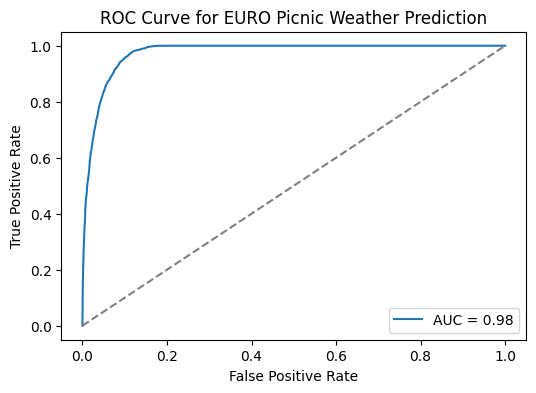

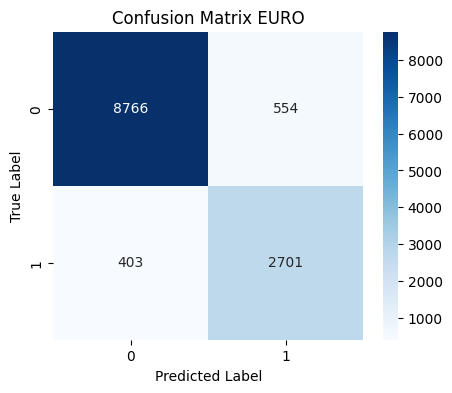

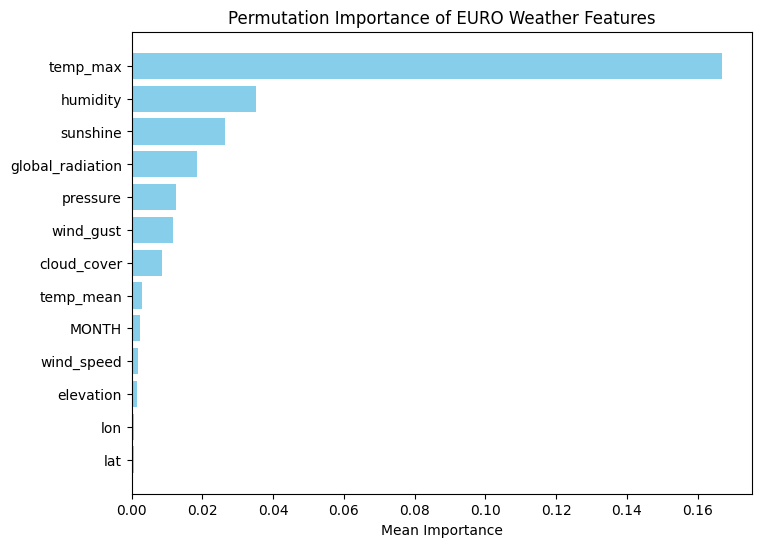

c:\Users\Trainee\Documents\dpp\portfolio\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:52:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Prediction accuracy for EURO picnic weather with XGBoost: 0.9247424339987121
AUC: 0.9766244787288173
Permutation importance calculated for the features.
XGBClassifier 			|	 TEST 		|	 TRAIN
-------------------------------------------------------------------------------------
True #IsBad:     			|	 3104 		|	 12232
True #NotBad:    			|	 9320 		|	 37462
F1-Score:        			|	 85.42 % 	|	 91.70 %
precision_score: 			|	 82.77 % 	|	 89.52 %
recall_score:    			|	 88.24 % 	|	 93.99 %
accuracy_score:  			|	 92.47 % 	|	 95.81 %


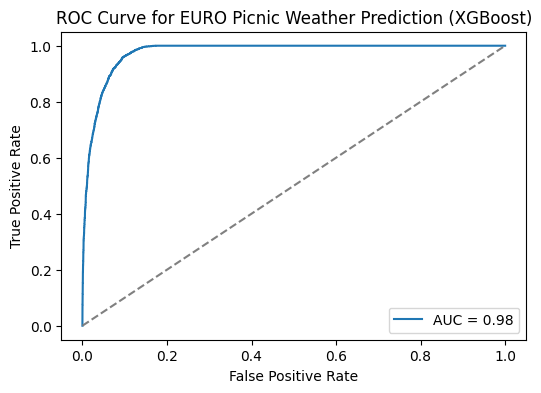

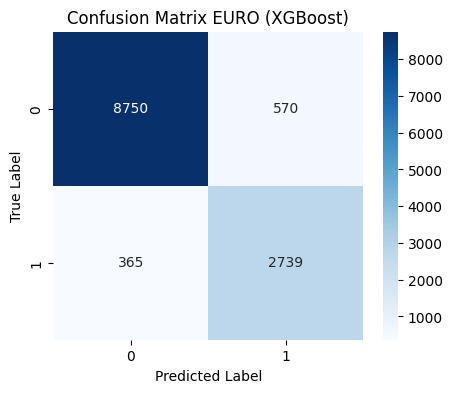

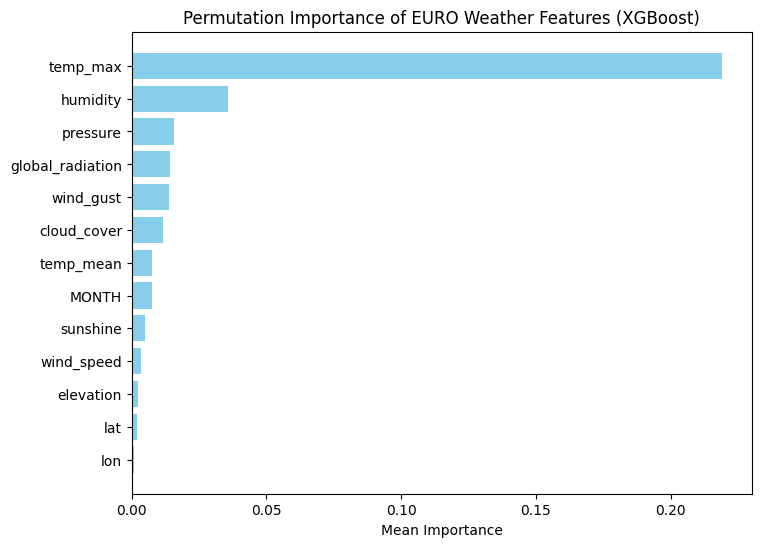

In [33]:
city_name = 'BASEL'
city_name = 'EURO'
# feature_cols = staedte_features[city_name]
# feature_cols = europe_features['EUROmin']
feature_cols = europe_features['EUROselect']
fit_model_for_city(city_name, weather_FS, feature_cols,
                   ['picnic_weather'], save_plot=False, show_plot=True)

fit_model_xgb(city_name, weather_FS, feature_cols,
                   ['picnic_weather'], save_plot=False, show_plot=True)


Prediction accuracy for EUROmin picnic weather: 0.8701706374758532
AUC: 0.9397434709747357
Permutation importance calculated for the features.
RandomForestClassifier 			|	 TEST 		|	 TRAIN
-------------------------------------------------------------------------------------
True #IsBad:     			|	 3104 		|	 12232
True #NotBad:    			|	 9320 		|	 37462
F1-Score:        			|	 75.44 % 	|	 99.30 %
precision_score: 			|	 71.53 % 	|	 98.65 %
recall_score:    			|	 79.80 % 	|	 99.95 %
accuracy_score:  			|	 87.02 % 	|	 99.65 %


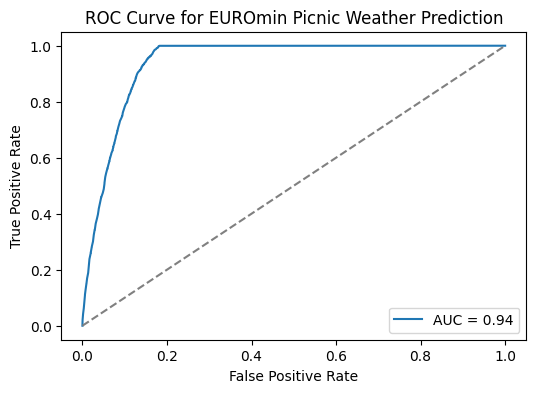

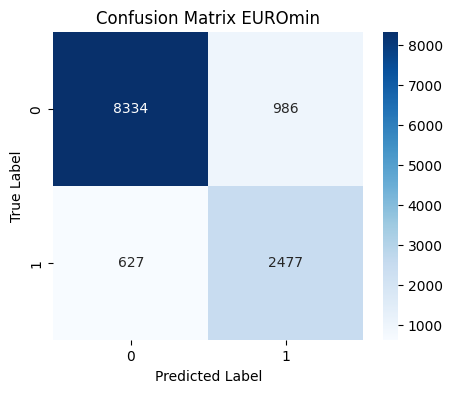

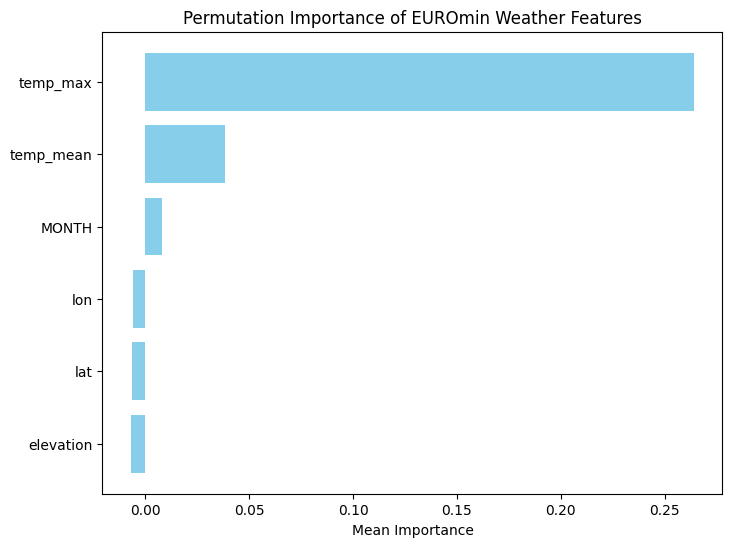

In [ ]:
fit_model_for_city('EUROmin', weather_FS, weather_FS['picnic_weather'],
                   europe_features['EUROmin'], save_plot=True, show_plot=True)
# fit_model_for_city('EUROselect', weather_FS, weather_FS['picnic_weather'],
#                    europe_features['EUROselect'], save_plot=True, show_plot=True)



In [ ]:
# Beispiel: Zugriff per Stadtname
# city_name = 'TOURS'
# feature_cols = staedte_features[city_name]
# fit_model_for_city(city_name, weather_light, picnic_labels, feature_cols)

unique_cities = list(staedte_features.keys()) # weather_FS['city'].unique()

for city in unique_cities:
    fit_model_for_city(city, weather_light, picnic_labels, 
                       staedte_features[city], save_plot=True, show_plot=False)

Prediction accuracy for BASEL picnic weather: 0.9028727770177839
AUC: 0.9652375095179523
Permutation importance calculated for the features.
RandomForestClassifier 			|	 TEST 		|	 TRAIN
-------------------------------------------------------------------------------------
True #IsBad:     			|	 189 		|	 748
True #NotBad:    			|	 542 		|	 2175
F1-Score:        			|	 81.75 % 	|	 100.00 %
precision_score: 			|	 79.50 % 	|	 100.00 %
recall_score:    			|	 84.13 % 	|	 100.00 %
accuracy_score:  			|	 90.29 % 	|	 100.00 %
Prediction accuracy for DE_BILT picnic weather: 1.0
AUC: 1.0
Permutation importance calculated for the features.
RandomForestClassifier 			|	 TEST 		|	 TRAIN
-------------------------------------------------------------------------------------
True #IsBad:     			|	 164 		|	 639
True #NotBad:    			|	 567 		|	 2284
F1-Score:        			|	 100.00 % 	|	 100.00 %
precision_score: 			|	 100.00 % 	|	 100.00 %
recall_score:    			|	 100.00 % 	|	 100.00 %
accuracy_score:  			|	 100.

In [ ]:
# For this analysis, we will predict BASEL_picnic_weather using BASEL weather features.

# Define feature columns and target variable
feature_cols = ['BASEL_cloud_cover', 'BASEL_humidity', 'BASEL_pressure', 'BASEL_global_radiation', 
                'BASEL_precipitation', 'BASEL_sunshine', 'BASEL_temp_mean', 'BASEL_temp_min', 'BASEL_temp_max']

# X = df[feature_cols]
# y = df['BASEL_picnic_weather']
X = weather_light[feature_cols]
y = picnic_labels['BASEL_picnic_weather']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Calculate prediction accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Prediction accuracy for BASEL picnic weather:', accuracy)

# Calculate ROC curve and AUC
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print('AUC:', roc_auc)

# Compute permutation importance
perm_importance = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42)
importances = perm_importance.importances_mean

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
feature_importance_df.sort_values(by='importance', ascending=True, inplace=True)

print('Permutation importance calculated for the features.')

Prediction accuracy for BASEL picnic weather: 1.0
AUC: 1.0
Permutation importance calculated for the features.


## Model Evaluation and Visualization

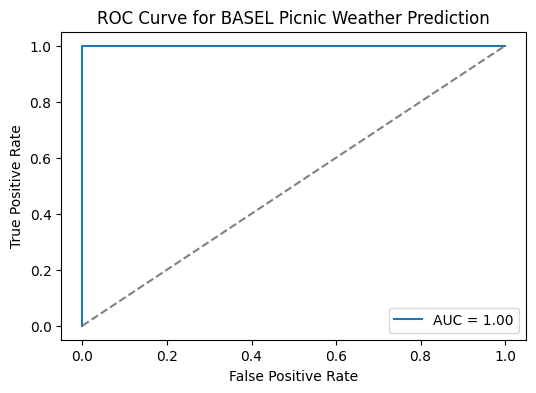

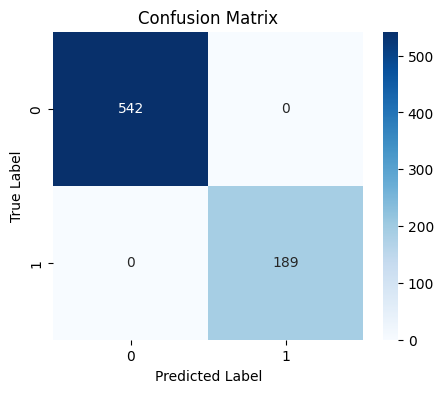

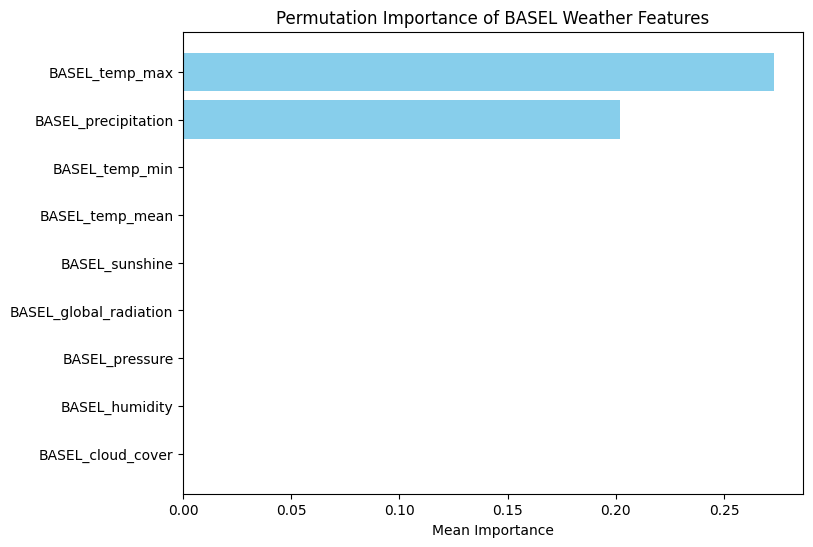

In [ ]:
# Plot ROC Curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for BASEL Picnic Weather Prediction')
plt.legend(loc='lower right')
plt.show()

# Plot Confusion Matrix using a heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Plot Permutation Importance
plt.figure(figsize=(8, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='skyblue')
plt.xlabel('Mean Importance')
plt.title('Permutation Importance of BASEL Weather Features')
plt.show()



---

## 4. Numerische Variablen analysieren



In [ ]:

# Statistiken für numerische Spalten
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    print(f"📊 {len(numeric_cols)} numerische Spalten gefunden\n")
    display(df[numeric_cols].describe().round(2).T)
else:
    print("⚠️ Keine numerischen Spalten gefunden")



📊 14 numerische Spalten gefunden



,count,mean,std,min,25%,50%,75%,max
MONTH,62118.0,6.52,3.45,1.00,4.00,7.00,10.00,12.00
cloud_cover,43848.0,5.27,2.39,-99.00,4.00,6.00,7.00,9.00
wind_speed,43848.0,3.33,1.89,0.00,2.00,2.90,4.30,16.30
wind_gust,25578.0,10.06,3.88,1.50,7.20,9.50,12.10,41.00
humidity,54810.0,0.75,0.14,0.10,0.66,0.77,0.86,1.00
pressure,51156.0,94.98,294.17,-99.00,1.01,1.02,1.02,1049.00
global_radiation,54810.0,1.35,0.96,0.01,0.52,1.17,2.09,4.42
precipitation,62118.0,0.23,0.58,0.00,0.00,0.00,0.20,16.04
sunshine,47502.0,4.85,4.41,-1.70,0.50,4.00,8.20,24.00
temp_mean,62118.0,10.05,8.37,-26.60,4.30,10.60,16.40,33.10


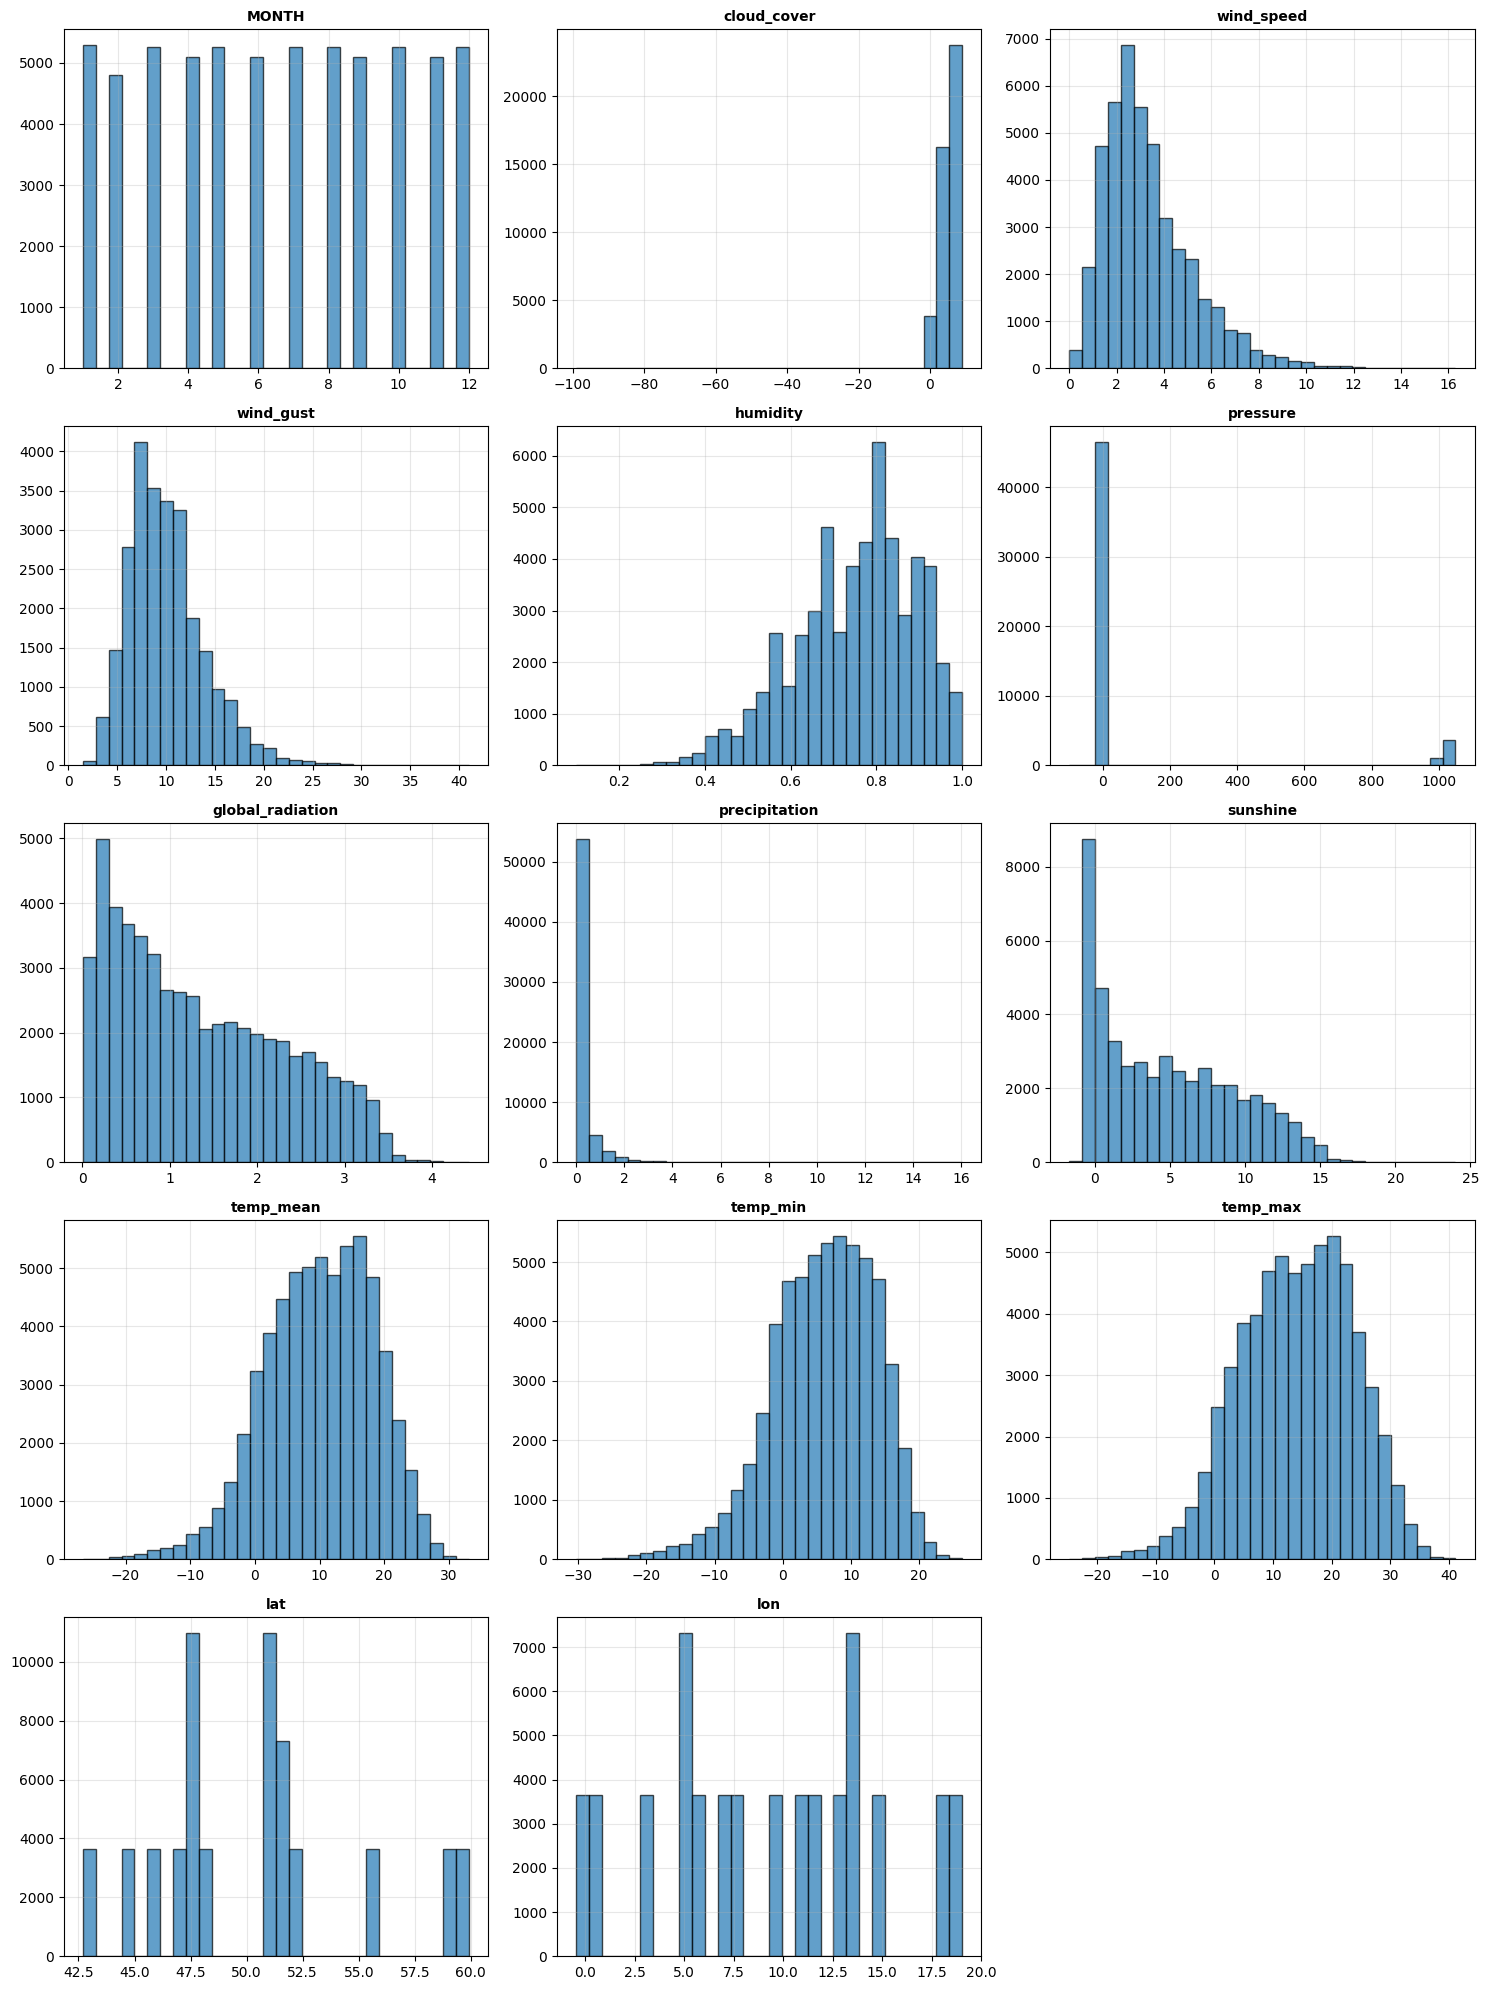

In [ ]:
# Verteilungen der numerischen Variablen
if numeric_cols:
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if len(numeric_cols) > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        df[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
        ax.set_title(f'{col}', fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3)
    
    # Leere Subplots ausblenden
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()




---

## 5. Kategorische Variablen analysieren



In [ ]:

# Kategorische Spalten identifizieren
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_cols:
    print(f"🏷️ {len(categorical_cols)} kategorische Spalten gefunden\n")
    
    cat_summary = pd.DataFrame({
        "Spalte": categorical_cols,
        "Unique Werte": [df[col].nunique() for col in categorical_cols],
        "Häufigste Werte": [df[col].value_counts().head(3).to_dict() for col in categorical_cols]
    })
    
    display(cat_summary)
else:
    print("⚠️ Keine kategorischen Spalten gefunden")


In [ ]:
# Top-Kategorien visualisieren (für Spalten mit wenigen Unique-Werten)
if categorical_cols:
    low_cardinality_cols = [col for col in categorical_cols if df[col].nunique() <= 20]
    
    if low_cardinality_cols:
        n_cols = min(2, len(low_cardinality_cols))
        n_rows = (len(low_cardinality_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
        axes = axes.flatten() if len(low_cardinality_cols) > 1 else [axes]
        
        for idx, col in enumerate(low_cardinality_cols):
            ax = axes[idx]
            value_counts = df[col].value_counts().head(10)
            value_counts.plot(kind='barh', ax=ax, color='steelblue')
            ax.set_title(f'Top Kategorien: {col}', fontsize=10, fontweight='bold')
            ax.set_xlabel('Anzahl')
            ax.grid(alpha=0.3, axis='x')
        
        # Leere Subplots ausblenden
        for idx in range(len(low_cardinality_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()




---

## 6. Korrelationsanalyse



In [ ]:

if len(numeric_cols) > 1:
    # Korrelationsmatrix
    corr_matrix = df[numeric_cols].corr()
    
    # Heatmap
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Obere Dreiecksmatrix maskieren
    
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        annot=True, 
        fmt='.2f',
        cmap='RdBu', 
        center=0, 
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
        ax=ax
    )
    
    ax.set_title('Korrelationsmatrix (numerische Variablen)', 
                 fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Stärkste Korrelationen finden
    print("\n🔗 Stärkste Korrelationen (|r| > 0.5):\n")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5:
                corr_pairs.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Korrelation': corr_matrix.iloc[i, j]
                })
    
    if corr_pairs:
        corr_df = pd.DataFrame(corr_pairs).sort_values('Korrelation', 
                                                        key=abs, 
                                                        ascending=False)
        display(corr_df)
    else:
        print("Keine starken Korrelationen gefunden.")
else:
    print("⚠️ Nicht genügend numerische Variablen für Korrelationsanalyse")




---

## 7. Fehlende Werte visualisieren



In [ ]:

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    fig, ax = plt.subplots(figsize=(10, max(6, len(missing_data) * 0.4)))
    
    missing_percent = (missing_data / len(df) * 100)
    missing_percent.plot(kind='barh', ax=ax, color='coral')
    
    ax.set_title('Fehlende Werte pro Spalte', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prozent fehlend (%)')
    ax.grid(alpha=0.3, axis='x')
    
    # Werte als Text hinzufügen
    for i, v in enumerate(missing_percent):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine fehlenden Werte im Dataset!")




---

## 8. Zusammenfassung & Bewertung



In [ ]:

print("=" * 80)
print("📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT")
print("=" * 80)

# Qualitätskriterien berechnen
data_quality = {
    "Datengröße": "✅ Gut" if len(df) > 5_000 else "⚠️ Klein" if len(df) > 1_000 else "❌ Zu klein",
    "Vollständigkeit": f"✅ {(1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.1f}%",
    "Duplikate": "✅ Keine" if df.duplicated().sum() == 0 else f"⚠️ {df.duplicated().sum()} gefunden",
    "Variablenvielfalt": f"{'✅' if df.shape[1] >= 10 else '⚠️'} {df.shape[1]} Spalten",
    "Numerische Features": f"{'✅' if len(numeric_cols) >= 5 else '⚠️'} {len(numeric_cols)} Spalten",
    "Kategorische Features": f"{'✅' if len(categorical_cols) >= 1 else '⚠️'} {len(categorical_cols)} Spalten"
}

for criterion, status in data_quality.items():
    print(f"{criterion:.<30} {status}")

print("\n" + "=" * 80)
print("💡 EMPFEHLUNG:")
print("=" * 80)

score = sum([
    len(df) > 5000,
    df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) < 0.1,
    df.duplicated().sum() < len(df) * 0.05,
    df.shape[1] >= 10,
    len(numeric_cols) >= 5
])

if score >= 4:
    print("✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!")
elif score >= 3:
    print("👍 OK - Dieses Dataset ist für ein Portfolio-Projekt geeignet.")
else:
    print("⚠️ BEDINGT - Überlege, ob dieses Dataset für dein Projekt ausreicht.")

print("\n📌 Nächste Schritte:")
print("   1. Definiere deine Forschungsfrage")
print("   2. Identifiziere relevante Features")
print("   3. Plane deine Analysestrategie")
print("   4. Beginne mit Feature Engineering & Modeling")
